# Importer les bibliothèque

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

#Normalisation
from sklearn.preprocessing import StandardScaler

#Les modèles
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

#Métriques d'evaluation
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
classification_report
)
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score

#validation croisé
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline

#Equilibrage
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

Ce code correspond à la phase d’initialisation d’un projet de classification supervisée en Python, où l’on importe l’ensemble des bibliothèques nécessaires pour traiter les données, construire les modèles et évaluer leurs performances. On commence par importer **pandas** et **numpy** pour la manipulation des données, ainsi que **matplotlib** et **seaborn** pour la visualisation. Ensuite, **StandardScaler** est importé pour la normalisation des variables. Plusieurs modèles de classification sont également importés, notamment la régression logistique, KNN, l’arbre de décision, la forêt aléatoire, le SVM et Naive Bayes, ce qui indique une volonté de comparer différentes approches. La fonction `train_test_split` est utilisée pour séparer les données en ensembles d’entraînement et de test. Les métriques d’évaluation comme l’accuracy, la précision, le recall, le F1-score, l’AUC, ainsi que la matrice de confusion et le rapport de classification sont importées pour analyser les performances des modèles. Enfin, le code inclut des outils de validation comme la validation croisée stratifiée, les pipelines pour structurer le processus d’apprentissage, ainsi que la méthode SMOTE pour gérer un éventuel déséquilibre des classes.


# 2.Présentation du dataset

In [2]:
df = pd.read_csv(r"C:\Users\alaou\Desktop\jupyter_Projects\DataSets CSV\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

Le dataset contient **284 807 lignes et 31 colonnes** : chaque ligne correspond à une observation (transaction) et chaque colonne à une variable (features + variable cible).


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

La majorité des variables sont de type **float64** (30 colonnes), ce qui indique des données numériques continues, tandis que la variable **Class** est de type **int64**, représentant la variable cible (classification binaire). On retrouve des variables nommées **V1 à V28**, ainsi que **Time** et **Amount**, déjà transformées par PCA.


In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
col=df.columns
col

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
col=df.select_dtypes(include=["number"]).columns
col

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [8]:
df.select_dtypes(include=["object"]).columns

Index([], dtype='object')

Toutes les colonnes du dataset sont **numériques**, incluant *Time*, *V1 à V28*, *Amount* et *Class*. Aucune variable de type **object** n’est présente, ce qui signifie qu’il n’y a pas de données catégorielles à encoder. Le dataset est donc entièrement prêt pour l’application directe des modèles de machine learning sans étape d’encodage supplémentaire.


## 2.6 Equilibre des classes

In [9]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

La variable cible est **fortement déséquilibrée** : la classe 0 (non fraude) contient **284 315 observations**, tandis que la classe 1 (fraude) ne contient que **492 observations**. Cela représente une proportion extrêmement faible de la classe minoritaire, ce qui peut biaiser les modèles vers la classe majoritaire et rendre l’accuracy trompeuse, d’où la nécessité d’utiliser des techniques comme **SMOTE** ou des métriques adaptées.


# 3.Analyse exploratoire des données (EDA)

In [10]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

<Axes: >

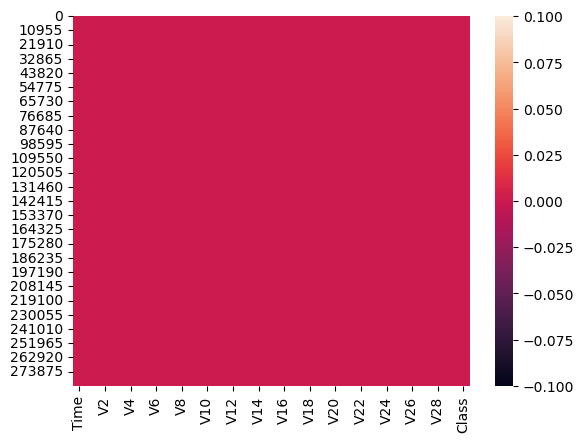

In [11]:
sns.heatmap(df.isna())

Aucune valeur manquante n’est présente dans le dataset : toutes les variables (Time, V1 à V28, Amount et Class) ont **0 valeurs nulles**, ce qui signifie que les données sont complètes et ne nécessitent aucun traitement de type imputation avant l’entraînement des modèles.


## 3.4 Analyse des corrélations

In [12]:
corr = df.corr()
print(corr)

            Time            V1            V2            V3            V4  \
Time    1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1      0.117396  1.000000e+00  4.135835e-16 -1.227819e-15 -9.215150e-16   
V2     -0.010593  4.135835e-16  1.000000e+00  3.243764e-16 -1.121065e-15   
V3     -0.419618 -1.227819e-15  3.243764e-16  1.000000e+00  4.711293e-16   
V4     -0.105260 -9.215150e-16 -1.121065e-15  4.711293e-16  1.000000e+00   
V5      0.173072  1.812612e-17  5.157519e-16 -6.539009e-17 -1.719944e-15   
V6     -0.063016 -6.506567e-16  2.787346e-16  1.627627e-15 -7.491959e-16   
V7      0.084714 -1.005191e-15  2.055934e-16  4.895305e-16 -4.104503e-16   
V8     -0.036949 -2.433822e-16 -5.377041e-17 -1.268779e-15  5.697192e-16   
V9     -0.008660 -1.513678e-16  1.978488e-17  5.568367e-16  6.923247e-16   
V10     0.030617  7.388135e-17 -3.991394e-16  1.156587e-15  2.232685e-16   
V11    -0.247689  2.125498e-16  1.975426e-16  1.576830e-15  3.459380e-16   
V12     0.12

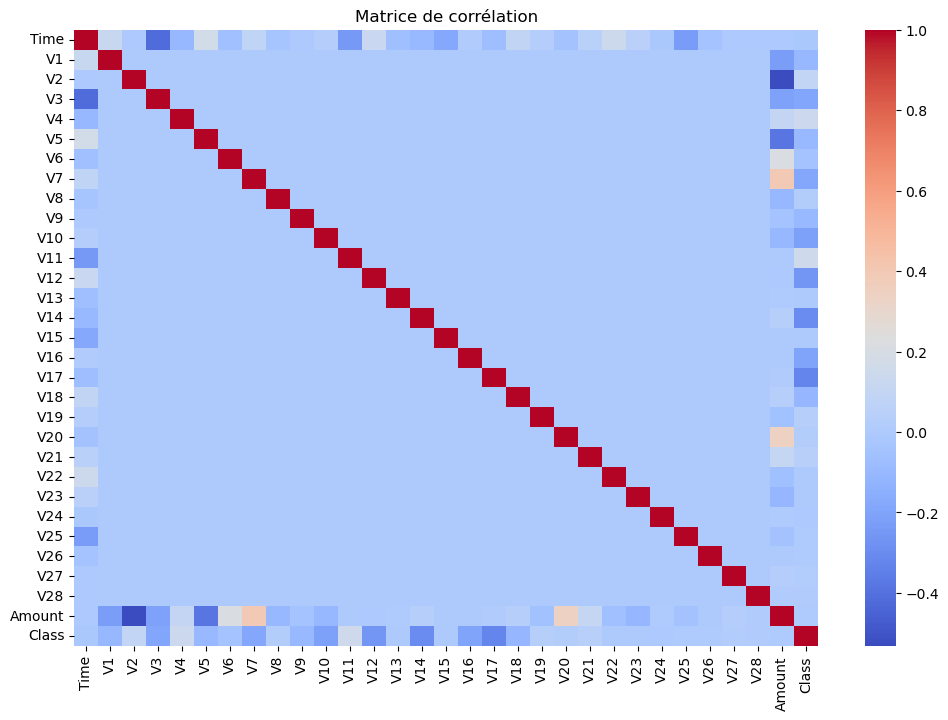

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

La matrice de corrélation montre que la majorité des variables (V1 à V28) sont **très faiblement corrélées entre elles**, ce qui est cohérent avec des données transformées (probablement par PCA). On observe également que la variable **Class** n’a pas de corrélation forte avec une seule variable spécifique, ce qui indique que la détection de fraude dépend d’une combinaison de plusieurs features plutôt que d’un seul facteur. La variable **Amount** présente quelques corrélations faibles avec certaines variables, tandis que **Time** est globalement peu corrélée avec les autres. Globalement, l’absence de fortes corrélations suggère un faible risque de multicolinéarité et confirme que le problème nécessite des modèles capables de capter des relations complexes entre variables.


## 3.5 Analyse des valeurs extrêmes (outliers)

In [14]:
for i in col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (df[i] < lower) | (df[i] > upper)

    print(i, ":", outliers.sum(), "outliers")

Time : 0 outliers
V1 : 7062 outliers
V2 : 13526 outliers
V3 : 3363 outliers
V4 : 11148 outliers
V5 : 12295 outliers
V6 : 22965 outliers
V7 : 8948 outliers
V8 : 24134 outliers
V9 : 8283 outliers
V10 : 9496 outliers
V11 : 780 outliers
V12 : 15348 outliers
V13 : 3368 outliers
V14 : 14149 outliers
V15 : 2894 outliers
V16 : 8184 outliers
V17 : 7420 outliers
V18 : 7533 outliers
V19 : 10205 outliers
V20 : 27770 outliers
V21 : 14497 outliers
V22 : 1317 outliers
V23 : 18541 outliers
V24 : 4774 outliers
V25 : 5367 outliers
V26 : 5596 outliers
V27 : 39163 outliers
V28 : 30342 outliers
Amount : 31904 outliers
Class : 492 outliers


Les variables présentent un nombre important d’outliers, notamment pour V8, V20, V27, V28 et Amount, ce qui indique une forte dispersion des données. Certaines variables comme V11 ou Time contiennent peu ou pas d’outliers, mais globalement le dataset est marqué par des valeurs extrêmes fréquentes. Cela est cohérent avec un problème de détection de fraude, où les transactions frauduleuses se distinguent souvent par des comportements atypiques.

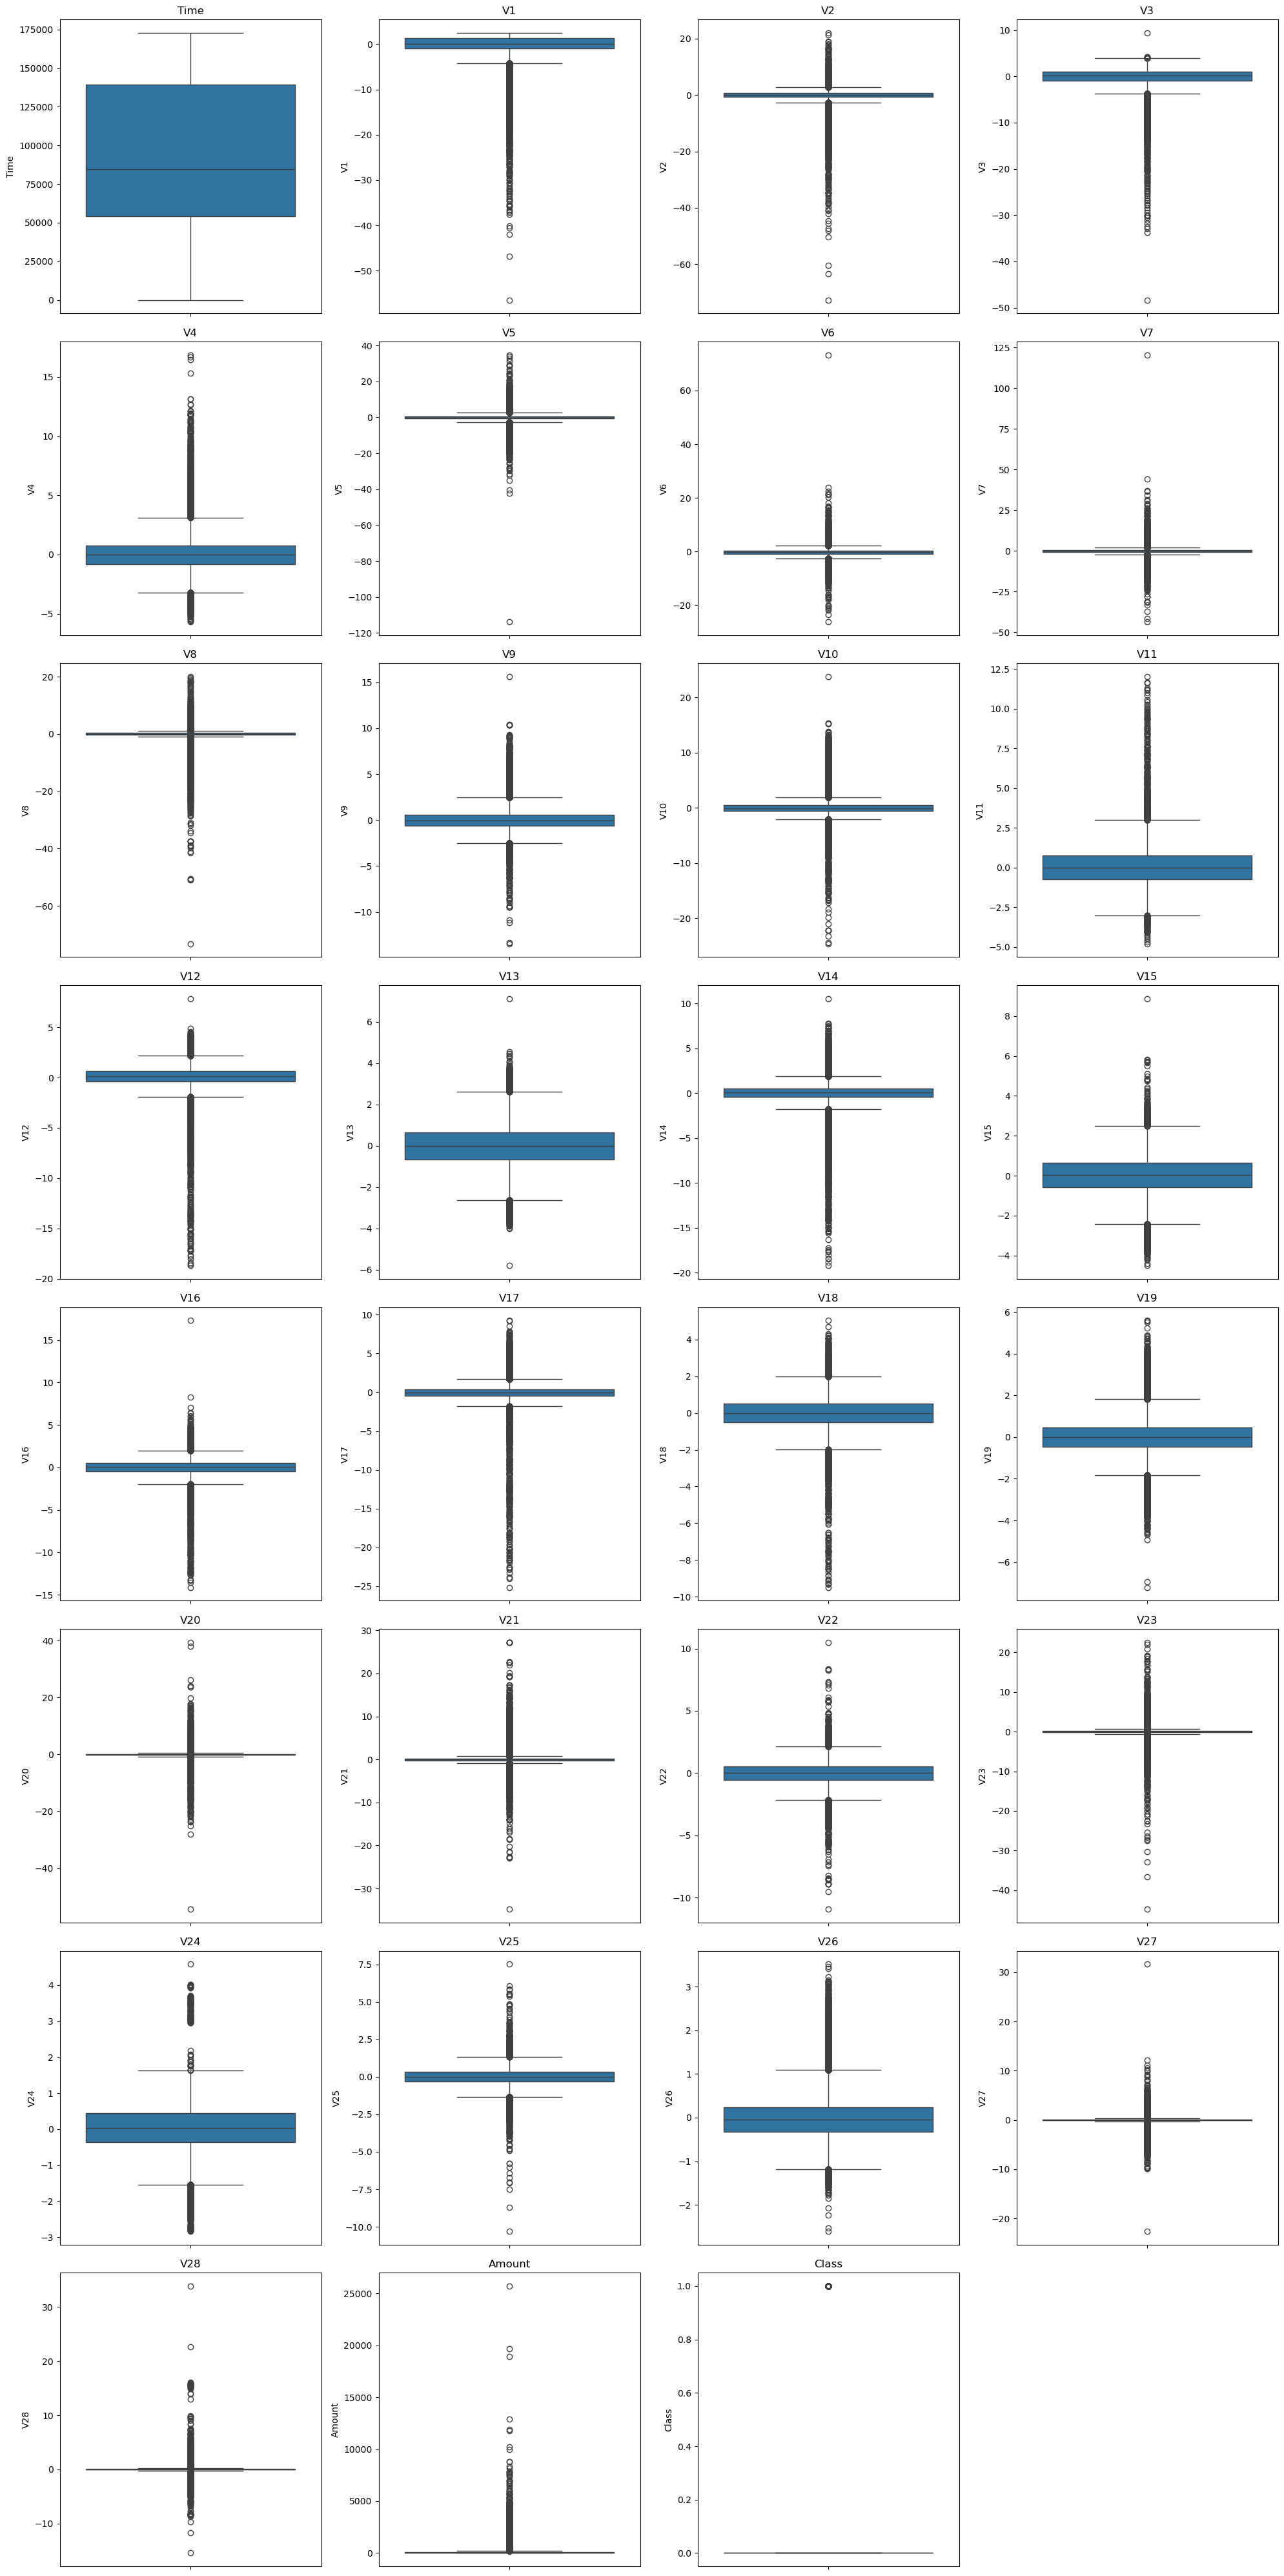

In [15]:
cols = df.columns
n = len(cols)
n_cols = 4
n_rows = math.ceil(n / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Les boxplots montrent que la majorité des variables (V1 à V28) sont **centrées autour de 0**, avec une dispersion variable selon les features, ce qui est cohérent avec des données transformées. On observe la présence de **nombreux outliers** dans presque toutes les variables, parfois très éloignés de la médiane, confirmant les résultats précédents. Certaines variables comme **V8, V20, V27, V28 et Amount** présentent une dispersion particulièrement importante avec des valeurs extrêmes marquées. La variable **Amount** est fortement asymétrique, avec quelques transactions très élevées. Globalement, ces visualisations montrent que les données contiennent des comportements atypiques significatifs, ce qui est caractéristique d’un problème de détection de fraude et nécessite l’utilisation de modèles robustes.


# 4.Prétraitement de données

## 4.2 Séparation de données (train/test)

In [8]:
x = df[['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
        'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
        'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']]

y = df['Class']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)
print("taille d'enssemble d'entrainement est : " ,x_train.shape)
print("taille d'enssemble de test est : " ,x_test.shape)

taille d'enssemble d'entrainement est :  (227845, 29)
taille d'enssemble de test est :  (56962, 29)


Les variables explicatives **X** sont constituées des features **V1 à V28 ainsi que Amount**, tandis que la variable cible **y** correspond à **Class**. Les données ont ensuite été séparées en deux ensembles : **80 % pour l’entraînement** et **20 % pour le test**, en utilisant un échantillonnage stratifié afin de conserver la proportion des classes. L’ensemble d’entraînement contient **227 845 observations** avec **29 variables**, tandis que l’ensemble de test contient **56 962 observations** avec **29 variables**, garantissant une évaluation fiable des performances du modèle sur des données non vues.


# 5.Modelisation 

## 5.2Régression logistique

### 5.2.1 Avant équilibrage

#### Définition du Modèle

In [18]:
model1 = LogisticRegression(class_weight='balanced')

pipeline_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model1)
])

#### Validation croisée du modèle

In [19]:
# Validation croisée stratifiée (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Accuracy sur chaque fold
scores = cross_val_score(
    pipeline_1,
    x_train, y_train, 
    cv=cv,
    scoring='recall'
)

print("Scores par fold :", scores)
print("recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.93589744 0.91139241 0.87341772 0.93670886 0.89873418]
recall moyen : 0.9112301200908796
Écart-type : 0.02384783053312516


#### Entrainement final

In [20]:
pipeline_1.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


#### Evaluation du modèle

In [21]:
y_pred1 = pipeline_1.predict(x_test)
y_prob1 = pipeline_1.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred1[:10])
print("Premières probabilités :", np.round(y_prob1[:10], 4))


Premières prédictions : [0 0 0 0 1 0 0 0 0 0]
Premières probabilités : [6.000e-03 5.930e-02 1.000e-04 1.900e-02 9.284e-01 1.790e-02 1.300e-03
 2.780e-02 5.420e-02 4.100e-03]


In [22]:
print("===== Logistic Regression ==============================")
print("Accuracy  :", accuracy_score(y_test, y_pred1))
print("Precision :", precision_score(y_test, y_pred1))
print("Recall    :", recall_score(y_test, y_pred1))
print("F1-score  :", f1_score(y_test, y_pred1))
print("AUC       :", roc_auc_score(y_test, y_prob1))

print("\nMatrice de confusion :==================================")
print(confusion_matrix(y_test, y_pred1))

print("\nRapport :===============================================")
print(classification_report(y_test, y_pred1))

===== Logistic Regression ==============================
Accuracy  : 0.974456655314069
Precision : 0.05855562784645413
Recall    : 0.9183673469387755
F1-score  : 0.11009174311926606
AUC       : 0.9714302223421727

Matrice de confusion :==================================
[[55417  1447]
 [    8    90]]

Rapport :===============================================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



### 5.2.2 Après equilibrage

#### Définition du Modèle

In [10]:
pipeline_1_equ = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

#### Validation croisée du modèle

In [11]:
# Validation croisée stratifiée (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# recall sur chaque fold
scores = cross_val_score(
    pipeline_1_equ,
    x_train, y_train,  
    cv=cv,
    scoring='recall'
)

print("Scores par fold :", scores)
print("recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.92307692 0.87341772 0.87341772 0.92405063 0.88607595]
recall moyen : 0.8960077896786757
Écart-type : 0.022971298833111033


#### Entrainement final

In [13]:
pipeline_1_equ.fit(x_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


#### Evaluation du modèle

In [14]:
y_pred1_equ = pipeline_1_equ.predict(x_test)
y_prob1_equ = pipeline_1_equ.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred1_equ[:10])
print("Premières probabilités :", np.round(y_prob1_equ[:10], 4))


Premières prédictions : [0 0 0 0 1 0 0 0 0 0]
Premières probabilités : [4.000e-04 2.430e-02 0.000e+00 1.200e-02 9.492e-01 5.500e-03 6.000e-04
 2.620e-02 2.810e-02 5.100e-03]


In [15]:
print("===== Logistic Regression ==============================")
print("Accuracy  :", accuracy_score(y_test, y_pred1_equ))
print("Precision :", precision_score(y_test, y_pred1_equ))
print("Recall    :", recall_score(y_test, y_pred1_equ))
print("F1-score  :", f1_score(y_test, y_pred1_equ))
print("AUC       :", roc_auc_score(y_test, y_prob1_equ))

print("\nMatrice de confusion :==================================")
print(confusion_matrix(y_test, y_pred1_equ))

print("\nRapport :===============================================")
print(classification_report(y_test, y_pred1_equ))

===== Logistic Regression ==============================
Accuracy  : 0.9811979916435518
Precision : 0.07732406602953953
Recall    : 0.9081632653061225
F1-score  : 0.14251401120896717
AUC       : 0.9720373817084516

Matrice de confusion :==================================
[[55802  1062]
 [    9    89]]

Rapport :===============================================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.91      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.57     56962
weighted avg       1.00      0.98      0.99     56962




AUC-PR : 0.7317


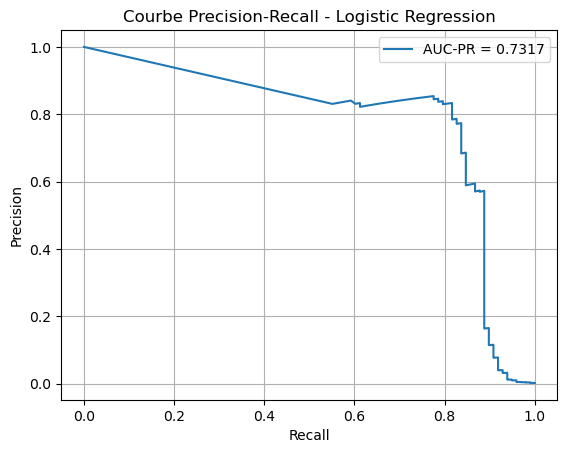

In [23]:
# Calcul courbe précision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob1_equ)

# Calcul AUC-PR
ap_score = average_precision_score(y_test, y_prob1_equ)
print("\nAUC-PR :", round(ap_score, 4))

# Plot
plt.figure()
plt.plot(recall, precision, label=f"AUC-PR = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

## 5.3 K plus proches voisins (KNN)

### 5.3.1 Avant équilibrage

#### Définition du Modèle

In [ ]:
model2 = KNeighborsClassifier(n_neighbors=5)

pipeline_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model2)
])

#### Validation croisée du modèle

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_2,
    x_train, y_train,
    cv=cv,
    scoring='recall'
)

print("Scores par fold :", scores)
print("recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.74358974 0.73417722 0.75949367 0.79746835 0.73417722]
recall moyen : 0.7537812398571891
Écart-type : 0.023722133169146807


#### Entrainement final

In [26]:
pipeline_2.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


#### Evaluation du modèle

In [27]:
y_pred2 = pipeline_2.predict(x_test)
y_prob2 = pipeline_2.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred2[:10])
print("Premières probabilités :", np.round(y_prob2[:10], 4))

np.unique(y_pred2, return_counts=True)


Premières prédictions : [0 0 0 0 0 0 0 0 0 0]
Premières probabilités : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


(array([0, 1]), array([56877,    85]))

In [29]:
print("===== KNN ============================================")
print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Precision :", precision_score(y_test, y_pred2))
print("Recall :", recall_score(y_test, y_pred2))
print("F1-score :", f1_score(y_test, y_pred2))
print("AUC :", roc_auc_score(y_test, y_prob2))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred2))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred2))

===== KNN ============================================
Accuracy : 0.9995611109160493
Precision : 0.9294117647058824
Recall : 0.8061224489795918
F1-score : 0.8633879781420765
AUC : 0.9437452984851791

==== Matrice de confusion : =========================
[[56858     6]
 [   19    79]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### 5.3.2 Après equilibrage

#### Définition du Modèle

In [16]:
model_2 = KNeighborsClassifier(n_neighbors=5)

pipeline_2_equ = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", model_2)
])

#### Validation croisée du modèle

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_2_equ,
    x_train, y_train,  
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

print("Scores par fold :", scores)
print("Recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.80769231 0.7721519  0.79746835 0.84810127 0.86075949]
Recall moyen : 0.8172346640701071
Écart-type : 0.03274561707430257


#### Entrainement final

In [30]:
pipeline_2_equ.fit(x_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5


#### Evaluation du modèle

In [31]:
y_pred2_equ = pipeline_2_equ.predict(x_test)
y_prob2_equ = pipeline_2_equ.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred2_equ[:10])
print("Premières probabilités :", np.round(y_prob2_equ[:10], 4))

np.unique(y_pred2_equ, return_counts=True)


Premières prédictions : [0 0 0 0 0 0 0 0 0 0]
Premières probabilités : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


(array([0, 1]), array([56760,   202]))

In [33]:
print("===== KNN ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred2_equ))
print("Precision :", precision_score(y_test, y_pred2_equ))
print("Recall :", recall_score(y_test, y_pred2_equ))
print("F1-score :", f1_score(y_test, y_pred2_equ))
print("AUC :", roc_auc_score(y_test, y_prob2_equ))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred2_equ))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred2_equ))

===== KNN ==================================
Accuracy : 0.9976124433833081
Precision : 0.40594059405940597
Recall : 0.8367346938775511
F1-score : 0.5466666666666666
AUC : 0.92281700771192

==== Matrice de confusion : =========================
[[56744   120]
 [   16    82]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.41      0.84      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.92      0.77     56962
weighted avg       1.00      1.00      1.00     56962




AUC-PR : 0.5566


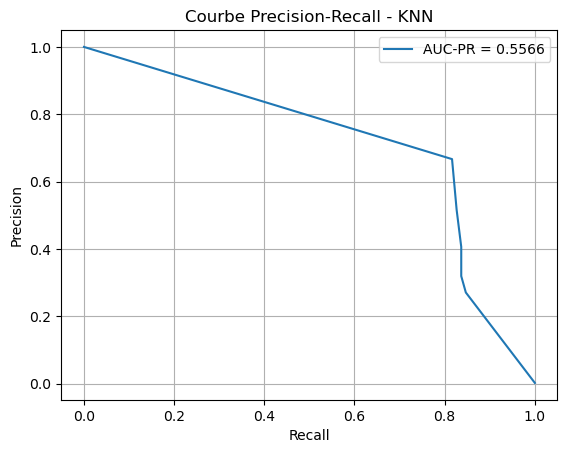

In [34]:
# Calcul courbe précision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob2_equ)

# Calcul AUC-PR
ap_score = average_precision_score(y_test, y_prob2_equ)
print("\nAUC-PR :", round(ap_score, 4))

# Plot
plt.figure()
plt.plot(recall, precision, label=f"AUC-PR = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - KNN")
plt.legend()
plt.grid()
plt.show()

## 5.4 Arbre de décision

### 5.4.1 Avant équilibrage

#### Définition du Modèle

In [45]:
model3 = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

pipeline_3 = Pipeline([ 
    ("model", model3)
])

#### Validation croisée du modèle

In [46]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_3,
    x_train, y_train,
    cv=cv,
    scoring='recall'   
)

print("Scores par fold :", scores)
print("recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.65384615 0.60759494 0.72151899 0.70886076 0.67088608]
recall moyen : 0.6725413826679649
Écart-type : 0.040714113907446677


#### Entrainement final

In [47]:
pipeline_3.fit(x_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


#### Evaluation du modèle

In [48]:
y_pred3 = pipeline_3.predict(x_test)
y_prob3 = pipeline_3.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred3[:10])
print("Premières probabilités :", np.round(y_prob3[:10], 4))

np.unique(y_pred3, return_counts=True)


Premières prédictions : [0 0 0 0 0 0 0 0 0 0]
Premières probabilités : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


(array([0, 1]), array([56863,    99]))

In [49]:
print("\n===== Random Forest ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred3))
print("Precision :", precision_score(y_test, y_pred3))
print("Recall :", recall_score(y_test, y_pred3))
print("F1-score :", f1_score(y_test, y_pred3))
print("AUC :", roc_auc_score(y_test, y_prob3))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred3))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred3))


===== Random Forest ==================================
Accuracy : 0.9989993328885924
Precision : 0.7070707070707071
Recall : 0.7142857142857143
F1-score : 0.7106598984771574
AUC : 0.8568878627703193

==== Matrice de confusion : =========================
[[56835    29]
 [   28    70]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.71      0.71        98

    accuracy                           1.00     56962
   macro avg       0.85      0.86      0.86     56962
weighted avg       1.00      1.00      1.00     56962



### 5.4.2 Après equilibrage

#### Définition du Modèle

In [40]:
model_3 = DecisionTreeClassifier(
    random_state=42
)

pipeline_3_equ = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", model_3)
])

#### Validation croisée du modèle

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_3_equ,
    x_train, y_train,  
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

print("Scores par fold :", scores)
print("Recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.82051282 0.65822785 0.75949367 0.84810127 0.79746835]
Recall moyen : 0.7767607919506654
Écart-type : 0.06600108878937917


#### Entrainement final

In [42]:
pipeline_3_equ.fit(x_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


#### Evaluation du modèle

In [43]:
y_pred3_equ = pipeline_3_equ.predict(x_test)
y_prob3_equ = pipeline_3_equ.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred3_equ[:10])
print("Premières probabilités :", np.round(y_prob3_equ[:10], 4))

np.unique(y_pred3_equ, return_counts=True)


Premières prédictions : [0 0 0 0 0 0 0 0 0 0]
Premières probabilités : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


(array([0, 1]), array([56797,   165]))

In [44]:
print("===== Decision Tree ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred3_equ))
print("Precision :", precision_score(y_test, y_pred3_equ))
print("Recall :", recall_score(y_test, y_pred3_equ))
print("F1-score :", f1_score(y_test, y_pred3_equ))
print("AUC :", roc_auc_score(y_test, y_prob3_equ))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred3_equ))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred3_equ))

===== Decision Tree ==================================
Accuracy : 0.9981917769741231
Precision : 0.48484848484848486
Recall : 0.8163265306122449
F1-score : 0.6083650190114068
AUC : 0.9074158680073042

==== Matrice de confusion : =========================
[[56779    85]
 [   18    80]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.48      0.82      0.61        98

    accuracy                           1.00     56962
   macro avg       0.74      0.91      0.80     56962
weighted avg       1.00      1.00      1.00     56962




AUC-PR : 0.3961


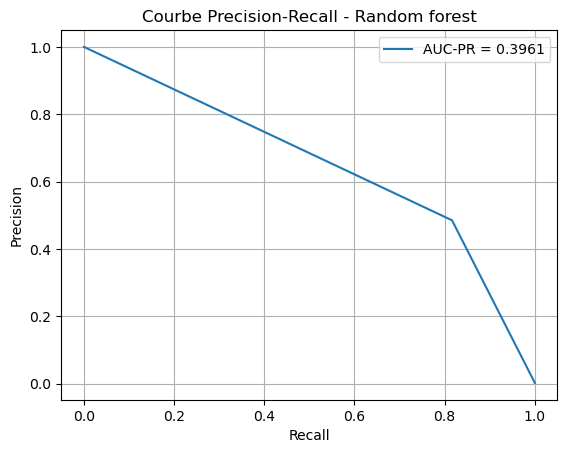

In [50]:
# Calcul courbe précision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob3_equ)

# Calcul AUC-PR
ap_score = average_precision_score(y_test, y_prob3_equ)
print("\nAUC-PR :", round(ap_score, 4))

# Plot
plt.figure()
plt.plot(recall, precision, label=f"AUC-PR = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Random forest")
plt.legend()
plt.grid()
plt.show()

## 5.5 Forêt aléatoire

### 5.5.1 Avant équilibrage

#### Définition du Modèle

In [51]:
model4 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

pipeline_4 = Pipeline([
    ("model", model4)
])

#### Validation croisée

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_4,
    x_train, y_train,
    cv=cv,
    scoring='recall'  
)

print("Scores par fold :", scores)
print("recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.73076923 0.6835443  0.72151899 0.79746835 0.7721519 ]
recall moyen : 0.7410905550146057
Écart-type : 0.03986078364790882


#### Entrainement final

In [53]:
pipeline_4.fit(x_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


#### Evaluation du modèle

In [54]:
y_pred4 = pipeline_4.predict(x_test)
y_prob4 = pipeline_4.predict_proba(x_test)[:, 1]


print("\nPremières prédictions :", y_pred4[:10])
print("Premières probabilités :", np.round(y_prob4[:10], 4))

np.unique(y_pred4, return_counts=True)


Premières prédictions : [0 0 0 0 0 0 0 0 0 0]
Premières probabilités : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


(array([0, 1]), array([56885,    77]))

In [55]:
print("===== Random Forest ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred4))
print("Precision :", precision_score(y_test, y_pred4))
print("Recall :", recall_score(y_test, y_pred4))
print("F1-score :", f1_score(y_test, y_pred4))
print("AUC :", roc_auc_score(y_test, y_prob4))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred4))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred4))

===== Random Forest ==================================
Accuracy : 0.9995259997893332
Precision : 0.961038961038961
Recall : 0.7551020408163265
F1-score : 0.8457142857142858
AUC : 0.9580130501131234

==== Matrice de confusion : =========================
[[56861     3]
 [   24    74]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### 5.5.2 Après équilibrage

#### Définition du Modèle

In [56]:
model_4 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

pipeline_4_equ = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", model_4)
])

#### Validation croisée

In [57]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_4_equ,
    x_train, y_train,  
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

print("Scores par fold :", scores)
print("Recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.84615385 0.73417722 0.75949367 0.88607595 0.83544304]
Recall moyen : 0.8122687439143135
Écart-type : 0.05659725581224602


#### Entrainement final

In [60]:
pipeline_4_equ.fit(x_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


#### Evaluation du modèle

In [61]:
y_pred4_equ = pipeline_4_equ.predict(x_test)
y_prob4_equ = pipeline_4_equ.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred4_equ[:10])
print("Premières probabilités :", np.round(y_prob4_equ[:10], 4))

np.unique(y_pred4_equ, return_counts=True)


Premières prédictions : [0 0 0 0 0 0 0 0 0 0]
Premières probabilités : [0.   0.   0.02 0.   0.   0.   0.   0.   0.   0.  ]


(array([0, 1]), array([56864,    98]))

In [62]:
print("===== Random Forest ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred4_equ))
print("Precision :", precision_score(y_test, y_pred4_equ))
print("Recall :", recall_score(y_test, y_pred4_equ))
print("F1-score :", f1_score(y_test, y_pred4_equ))
print("AUC :", roc_auc_score(y_test, y_prob4_equ))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred4_equ))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred4_equ))

===== Random Forest ==================================
Accuracy : 0.9994733330992591
Precision : 0.8469387755102041
Recall : 0.8469387755102041
F1-score : 0.8469387755102041
AUC : 0.9680177659837148

==== Matrice de confusion : =========================
[[56849    15]
 [   15    83]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962




AUC-PR : 0.8827


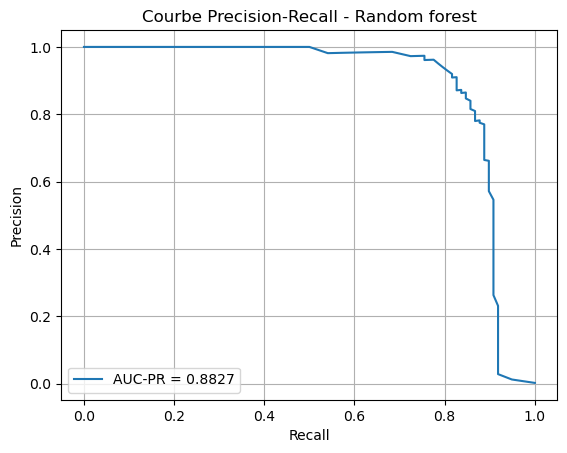

In [63]:
# Calcul courbe précision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob4_equ)

# Calcul AUC-PR
ap_score = average_precision_score(y_test, y_prob4_equ)
print("\nAUC-PR :", round(ap_score, 4))

# Plot
plt.figure()
plt.plot(recall, precision, label=f"AUC-PR = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Random forest")
plt.legend()
plt.grid()
plt.show()

## 5.6 Machine à vecteurs de support (SVM)

### 5.6.1 Avant équilibrage

#### Définition du Modèle

In [64]:
model5 = LinearSVC(
    random_state=42,
    class_weight='balanced',
    dual='auto'  # pour éviter les warnings
)

pipeline_5 = Pipeline([
    ("scaler", StandardScaler()),   # OBLIGATOIRE pour LinearSVC
    ("model", model5)
])

#### Validation croisée du modèle

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_5,
    x_train, y_train,
    cv=cv,
    scoring='recall'
)

print("Scores par fold :", scores)
print("recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.93589744 0.89873418 0.87341772 0.93670886 0.88607595]
recall moyen : 0.906166828951639
Écart-type : 0.025877080547345676


#### Entrainement final

In [66]:
pipeline_5.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


#### Evaluation du modèle

In [67]:
y_pred5 = pipeline_5.predict(x_test)
y_score5 = pipeline_5.decision_function(x_test)  # au lieu de predict_proba

print("\nPremières prédictions :", y_pred5[:10])
print("Premières distances :", np.round(y_score5[:10], 4))


Premières prédictions : [0 0 0 0 1 0 0 0 0 0]
Premières distances : [-1.2457 -0.8999 -1.3802 -1.1486  0.6659 -0.9201 -1.4487 -1.0875 -0.7813
 -1.4655]


In [68]:
print("===== LinearSVC ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred5))
print("Precision :", precision_score(y_test, y_pred5))
print("Recall :", recall_score(y_test, y_pred5))
print("F1-score :", f1_score(y_test, y_pred5))
print("AUC :", roc_auc_score(y_test, y_score5))  # decision_function fonctionne

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred5))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred5))

===== LinearSVC ==================================
Accuracy : 0.9789508795337243
Precision : 0.06958561376075059
Recall : 0.9081632653061225
F1-score : 0.12926652142338416
AUC : 0.9737477820334662

==== Matrice de confusion : =========================
[[55674  1190]
 [    9    89]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.13        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



### 5.6.2 Après equilibrage

#### Définition du Modèle

In [69]:
model_5 = LinearSVC(
    random_state=42,
    dual="auto",
    max_iter=5000
)

pipeline_5_equ = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()), 
    ("model", model_5)
])

#### Validation croisée du modèle

In [70]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_5_equ,
    x_train, y_train, 
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

print("Scores par fold :", scores)
print("Recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.92307692 0.86075949 0.86075949 0.93670886 0.87341772]
Recall moyen : 0.8909444985394354
Écart-type : 0.0324232216370281


#### Entrainement final

In [71]:
pipeline_5_equ.fit(x_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


#### Evaluation du modèle

In [72]:
y_pred5_equ = pipeline_5_equ.predict(x_test)
y_score5_equ = pipeline_5_equ.decision_function(x_test)

print("\nPremières prédictions :", y_pred5_equ[:10])
print("Premières distances :", np.round(y_score5_equ[:10], 4))


Premières prédictions : [0 0 0 0 1 0 0 0 0 0]
Premières distances : [-1.6816 -1.0711 -2.0523 -1.1919  0.7159 -1.0941 -1.4953 -1.0369 -0.9198
 -1.3192]


In [73]:
print("===== LinearSVC (Après équilibrage) ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred5_equ))
print("Precision :", precision_score(y_test, y_pred5_equ))
print("Recall :", recall_score(y_test, y_pred5_equ))
print("F1-score :", f1_score(y_test, y_pred5_equ))
print("AUC :", roc_auc_score(y_test, y_score5_equ))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred5_equ))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred5_equ))

===== LinearSVC (Après équilibrage) ==================================
Accuracy : 0.9843228819212808
Precision : 0.09146968139773895
Recall : 0.9081632653061225
F1-score : 0.16619981325863678
AUC : 0.9734195732316562

==== Matrice de confusion : =========================
[[55980   884]
 [    9    89]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.09      0.91      0.17        98

    accuracy                           0.98     56962
   macro avg       0.55      0.95      0.58     56962
weighted avg       1.00      0.98      0.99     56962




AUC-PR : 0.755


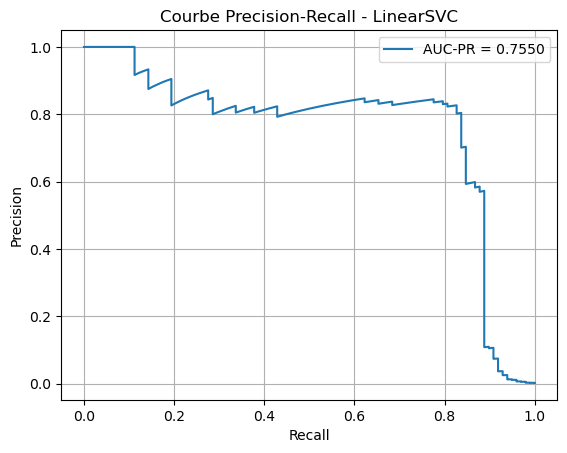

In [74]:
# Calcul courbe précision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score5_equ)

# Calcul AUC-PR
ap_score = average_precision_score(y_test, y_score5_equ)
print("\nAUC-PR :", round(ap_score, 4))

# Plot
plt.figure()
plt.plot(recall, precision, label=f"AUC-PR = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - LinearSVC")
plt.legend()
plt.grid()
plt.show()

## 5.7 Naive Bayes

### 5.7.1 Avant équilibrage

#### Définition du Modèle

In [75]:
model6 = GaussianNB()

pipeline_6 = Pipeline([
    ("scaler", StandardScaler()),  
    ("model", model6)
])

#### Validation croisée du modèle

In [76]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_6,
    x_train, y_train,
    cv=cv,
    scoring='recall'
)

print("Scores par fold :", scores)
print("recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.84615385 0.78481013 0.79746835 0.92405063 0.7721519 ]
recall moyen : 0.8249269717624148
Écart-type : 0.05554210234072332


#### Entrainement final

In [77]:
pipeline_6.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,priors,None
,var_smoothing,1e-09


#### Evaluation du modèle

In [78]:
y_pred6 = pipeline_6.predict(x_test)
y_prob6 = pipeline_6.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred6[:10])
print("Premières probabilités :", np.round(y_prob6[:10], 4))

np.unique(y_pred6, return_counts=True)


Premières prédictions : [0 0 1 0 0 0 0 0 0 0]
Premières probabilités : [0.     0.     0.9622 0.     0.     0.     0.     0.     0.     0.    ]


(array([0, 1]), array([55549,  1413]))

In [79]:
print("===== Naive Bayes ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred6))
print("Precision :", precision_score(y_test, y_pred6))
print("Recall :", recall_score(y_test, y_pred6))
print("F1-score :", f1_score(y_test, y_pred6))
print("AUC :", roc_auc_score(y_test, y_prob6))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred6))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred6))

===== Naive Bayes ==================================
Accuracy : 0.9763877672834521
Precision : 0.05874026893135174
Recall : 0.8469387755102041
F1-score : 0.10986101919258769
AUC : 0.9628564178907354

==== Matrice de confusion : =========================
[[55534  1330]
 [   15    83]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.85      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91      0.55     56962
weighted avg       1.00      0.98      0.99     56962



### 5.7.2 Après equilibrage

#### Définition du Modèle

In [81]:
model_6 = GaussianNB()

pipeline_6_equ = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", model_6)
])

#### Validation croisée du modèle

In [82]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_6_equ,
    x_train, y_train, 
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

print("Scores par fold :", scores)
print("Recall moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores par fold : [0.8974359  0.79746835 0.82278481 0.93670886 0.82278481]
Recall moyen : 0.8554365465757872
Écart-type : 0.05265304855817806


#### Entrainement final

In [83]:
pipeline_6_equ.fit(x_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,priors,None
,var_smoothing,1e-09


#### Evaluation du modèle

In [84]:
y_pred6_equ = pipeline_6_equ.predict(x_test)
y_prob6_equ = pipeline_6_equ.predict_proba(x_test)[:, 1]

print("\nPremières prédictions :", y_pred6_equ[:10])
print("Premières probabilités :", np.round(y_prob6_equ[:10], 4))

np.unique(y_pred6_equ, return_counts=True)


Premières prédictions : [0 0 1 0 0 0 0 0 0 0]
Premières probabilités : [0.     0.     0.9999 0.     0.     0.     0.     0.     0.     0.    ]


(array([0, 1]), array([55344,  1618]))

In [ ]:
print("===== Naive Bayes ==================================")
print("Accuracy :", accuracy_score(y_test, y_pred6_equ))
print("Precision :", precision_score(y_test, y_pred6_equ))
print("Recall :", recall_score(y_test, y_pred6_equ))
print("F1-score :", f1_score(y_test, y_pred6_equ))
print("AUC :", roc_auc_score(y_test, y_prob6_equ))

print("\n==== Matrice de confusion : =========================")
print(confusion_matrix(y_test, y_pred6_equ))

print("\n==== Rapport : ======================================")
print(classification_report(y_test, y_pred6_equ))

===== Naive Bayes ==================================
Accuracy : 0.9728942101752045
Precision : 0.05315203955500618
Recall : 0.8775510204081632
F1-score : 0.10023310023310024
AUC : 0.963847594116431

==== Matrice de confusion : =========================
[[55332  1532]
 [   12    86]]

==== Rapport : ======================================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.88      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.93      0.54     56962
weighted avg       1.00      0.97      0.98     56962




AUC-PR : 0.0827


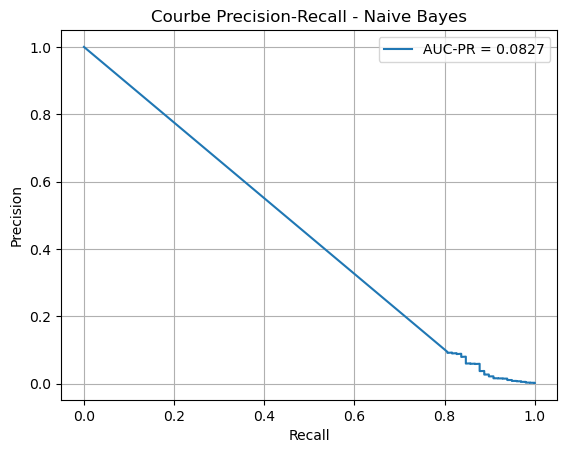

In [86]:
# Calcul courbe précision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob6_equ)

# Calcul AUC-PR
ap_score = average_precision_score(y_test, y_prob6_equ)
print("\nAUC-PR :", round(ap_score, 4))

# Plot
plt.figure()
plt.plot(recall, precision, label=f"AUC-PR = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Naive Bayes")
plt.legend()
plt.grid()
plt.show()

## Matrices de confusion

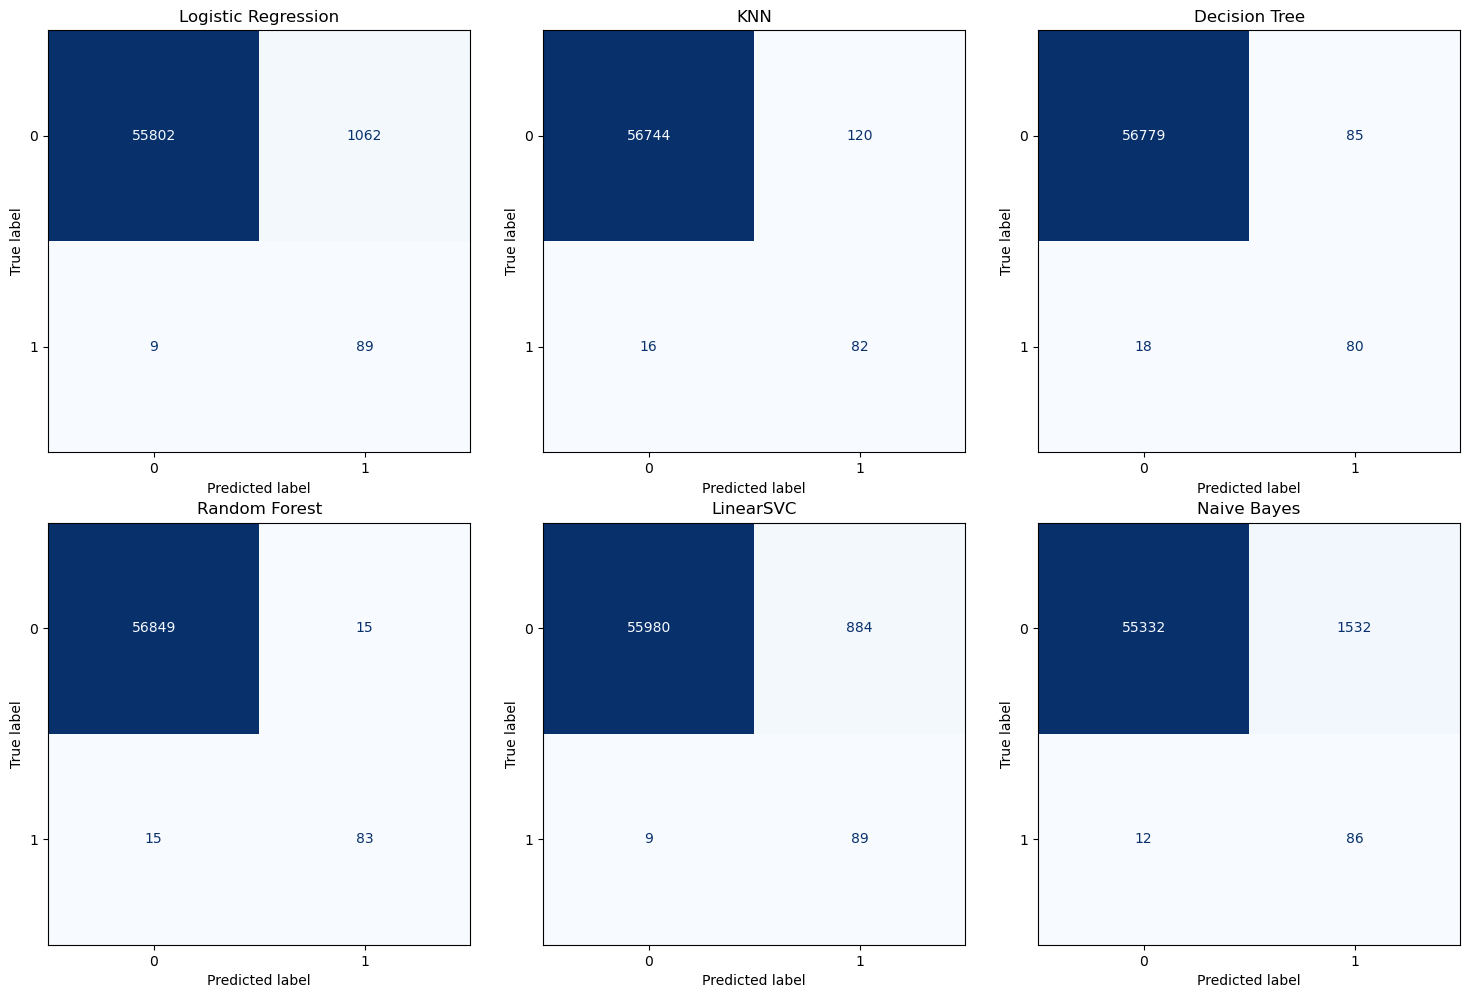

In [ ]:
# prédictions déjà calculées
y_preds = [y_pred1_equ, y_pred2_equ, y_pred3_equ, y_pred4_equ, y_pred5_equ, y_pred6_equ]

# Noms des modèles
model_names = [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "LinearSVC",
    "Naive Bayes"
]

# Figure
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.ravel()

# Boucle
for i in range(6):
    cm = confusion_matrix(y_test, y_preds[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    
    axes[i].set_title(model_names[i])

plt.tight_layout()
plt.show()

# Comparaison des 6 modèles

## Performances

In [ ]:
resultats = {
    "Modèle": [
        "Logistic Regression", "KNN", "Decision Tree",
        "Random Forest", "LinearSVC", "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred1_equ),
        accuracy_score(y_test, y_pred2_equ),
        accuracy_score(y_test, y_pred3_equ),
        accuracy_score(y_test, y_pred4_equ),
        accuracy_score(y_test, y_pred5_equ),
        accuracy_score(y_test, y_pred6_equ),
    ],
    "Precision": [
        precision_score(y_test, y_pred1_equ),
        precision_score(y_test, y_pred2_equ),
        precision_score(y_test, y_pred3_equ),
        precision_score(y_test, y_pred4_equ),
        precision_score(y_test, y_pred5_equ),
        precision_score(y_test, y_pred6_equ),
    ],
    "Recall": [
        recall_score(y_test, y_pred1_equ),
        recall_score(y_test, y_pred2_equ),
        recall_score(y_test, y_pred3_equ),
        recall_score(y_test, y_pred4_equ),
        recall_score(y_test, y_pred5_equ),
        recall_score(y_test, y_pred6_equ),
    ],
    "F1-Score": [
        f1_score(y_test, y_pred1_equ),
        f1_score(y_test, y_pred2_equ),
        f1_score(y_test, y_pred3_equ),
        f1_score(y_test, y_pred4_equ),
        f1_score(y_test, y_pred5_equ),
        f1_score(y_test, y_pred6_equ),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob1_equ),
        roc_auc_score(y_test, y_prob2_equ),
        roc_auc_score(y_test, y_prob3_equ),
        roc_auc_score(y_test, y_prob4_equ),
        roc_auc_score(y_test, y_score5_equ),
        roc_auc_score(y_test, y_prob6_equ),
    ],
}

df_resultats = pd.DataFrame(resultats).set_index("Modèle")

df_resultats.round(4).style \
    .background_gradient(cmap="YlGn") \
    .format("{:.4f}") \
    .set_caption(" Comparaison des 6 modèles — Credit Card Fraud Detection")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.9812,0.0773,0.9082,0.1425,0.9720
KNN,0.9976,0.4059,0.8367,0.5467,0.9228
Decision Tree,0.9982,0.4848,0.8163,0.6084,0.9074
Random Forest,0.9995,0.8469,0.8469,0.8469,0.9680
LinearSVC,0.9843,0.0915,0.9082,0.1662,0.9734
Naive Bayes,0.9729,0.0532,0.8776,0.1002,0.9638


## Courbes precision-recall

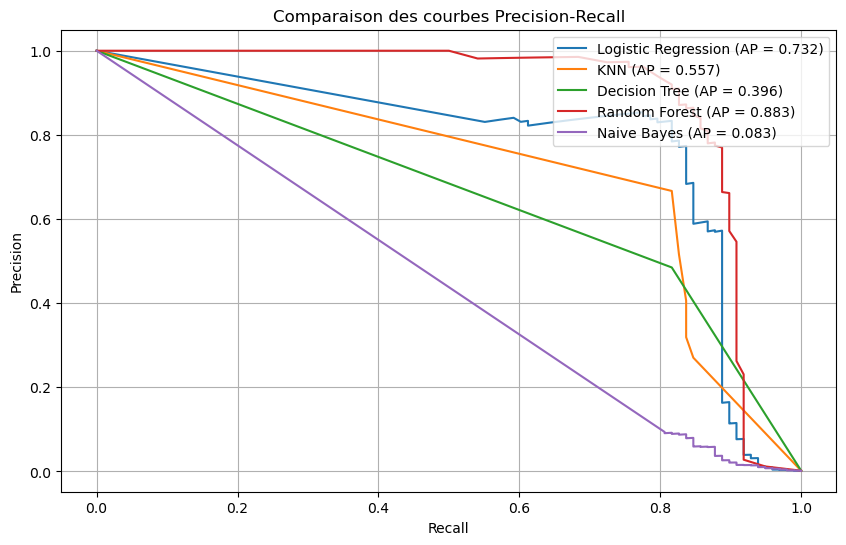

In [91]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Dictionnaire des pipelines et leurs probabilités
modeles = {
    'Logistic Regression': (pipeline_1_equ, y_prob1_equ),
    'KNN':                 (pipeline_2_equ, y_prob2_equ),
    'Decision Tree':       (pipeline_3_equ, y_prob3_equ),
    'Random Forest':       (pipeline_4_equ, y_prob4_equ),
    'Naive Bayes':         (pipeline_6_equ, y_prob6_equ),
}

plt.figure(figsize=(10, 6))

for nom, (pipeline, y_prob) in modeles.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{nom} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparaison des courbes Precision-Recall')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()